# FFTPSF Colour Fringe Analysis

This notebook computes **Colour Fringe Width (CFW)** using the FFT-based PSF route, where each wavelength's PSF is obtained via FFT diffraction propagation through the full lens prescription.

**Pipeline**: Lens model → spectral weighting → FFT PSF baking (raw ESF) → tone mapping → CFW detection

The baking stage is purely optical and independent of display parameters (exposure, gamma, threshold).
All subsequent analysis cells re-use the cached raw ESFs with different tone-mapping settings.

For analytic PSF model comparisons (Pillbox / Gaussian / Double-Gaussian / Geometric Fast), see [`cfw_geom_demo.ipynb`](cfw_geom_demo.ipynb).

In [1]:
# ───────────────────────────── Imports ─────────────────────────────
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from chromf import channel_products, compute_polychromatic_esf
from optiland import fileio
from optiland.physical_apertures import RadialAperture

## 1. Lens Model

Load the Zemax lens file and apply measured clear-aperture constraints to each surface.

FNO 1 = 2.0，focal length 1 = 85.00003717952896 mm


(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

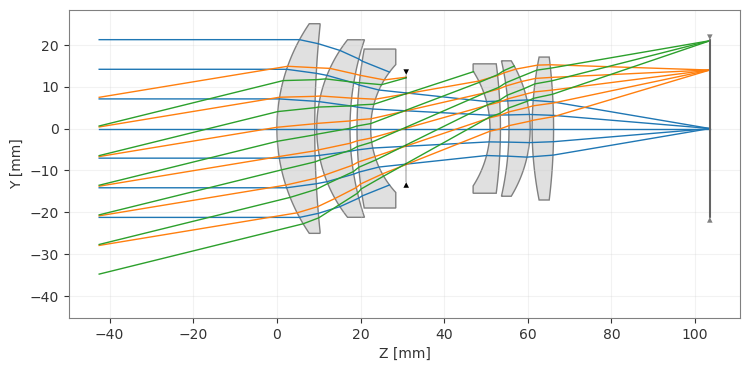

In [ ]:
lens1 = fileio.load_zemax_file(str(Path("..") / "data" / "lens" / "NikonAINikkor85mmf2S.zmx"))
clear_semi_diameters = [
            None, 25.062, 24.642, 21.225, 21.225, 19.006, 15.289,
            12.836, 13.730, 15.469, 16.188, 16.188, 17.088, 17.088, 21.190
        ]
for i, r in enumerate(clear_semi_diameters):
            if r is not None:
                lens1.surface_group.surfaces[i].aperture = RadialAperture(r_max=r)
print(f"FNO 1 = {lens1.paraxial.FNO()}，focal length 1 = {lens1.paraxial.f2()} mm")
lens1.draw(num_rays=7)


## 2. Spectral Data & Display Constants

Load sensor spectral responses (R/G/B × D65 illuminant products) and define the tone-mapping function.

The tone curve converts a raw (linear) ESF value to a display-referred response:

$$\text{tone}(x) = \left(\frac{\tanh(e \cdot x)}{\tanh(e)}\right)^\gamma$$

where $e$ is the exposure slope and $\gamma$ is the display gamma. This is applied **after** baking, so exposure and gamma can be varied freely without re-computing the optics.

In [3]:
# ──────────────────────────── Data load ────────────────────────────
prods = channel_products()
sensor_wl = prods["blue"][:, 0]   # nm
wl = sensor_wl

FN_DEFAULT = float(lens1.paraxial.FNO())
print(f"FNO = {FN_DEFAULT}, focal length = {lens1.paraxial.f2()} mm")

FNO = 2.0, focal length = 85.00003717952896 mm


In [4]:
# ──────────────────────────── Constants ─────────────────────────────
GAMMA_DEFAULT        = 2.2
COLOR_DIFF_THRESHOLD = 0.15


def _tone_map(esf: np.ndarray, gamma: float = GAMMA_DEFAULT,
              exposure: float = 4.0) -> np.ndarray:
    """Tone-map a raw ESF: (tanh(exp·x) / tanh(exp))^γ"""
    return (np.tanh(exposure * esf) / np.tanh(exposure)) ** gamma

## 3. PSF Baking (Pure Optics)

For each defocus position $z$ and each RGB channel, compute the polychromatic Edge Spread Function (ESF) via FFT diffraction propagation through the lens.

This is the most expensive step. The results are **raw linear ESFs** — no tone mapping, no threshold — and are cached in `_esf_raw_cache` for reuse by all downstream cells.

**Sampling parameters:**
- `num_rays = 400`: pupil sampling density (supports up to ~50 waves of defocus phase → |z| ≤ 800 µm)
- `grid_size = 512`: FFT grid (Q = 512/399 ≈ 1.28, sufficient for defocused PSFs)
- `wl_stride = 3`: spectral sub-sampling (31 → ~11 wavelengths per channel)

In [5]:
# ── FFTPSF: PSF baking (pure optics, no tone mapping) ─────────────────────────
# Computes raw polychromatic ESF for each (z, channel) and caches them.
# This cell is independent of exposure, gamma, and threshold.
#
# PSF grid parameters (num_rays=400, grid_size=512):
#   Q = 512 / 399 ≈ 1.28  (acceptable for |z| >> λ·FNO² ≈ 2 µm)

_X_UM      = np.arange(-400, 401, dtype=float)   # 801 µm, 1 µm step
_NUM_RAYS  = 400
_GRID_SIZE = 512
_WL_STRIDE = 3
_STRATEGY  = "chief_ray"

_Z_MIN_BAKE  = -800
_Z_MAX_BAKE  =  400
_Z_STEP_BAKE =   50
_z_bake = np.arange(_Z_MIN_BAKE, _Z_MAX_BAKE + _Z_STEP_BAKE, _Z_STEP_BAKE)

_n = len(_z_bake)
_esf_raw_cache = {}   # {(z_index, channel): ndarray}

# ESF transition width (raw, exposure-independent)
_trans_width = {c: np.zeros(_n, dtype=np.int32) for c in ("R", "G", "B")}

for _i, _z in enumerate(_z_bake):
    for _c in ("R", "G", "B"):
        _raw = compute_polychromatic_esf(
            lens1, _c, float(_z), _X_UM,
            num_rays=_NUM_RAYS, grid_size=_GRID_SIZE,
            wl_stride=_WL_STRIDE, strategy=_STRATEGY,
        )
        _esf_raw_cache[(_i, _c)] = _raw
        _trans_width[_c][_i] = int(np.sum((_raw > 0.05) & (_raw < 0.95)))

    print(f"[{_i+1:>2}/{_n}]  z={_z:+6.0f} µm  "
          f"R_tr={_trans_width['R'][_i]:>3}  "
          f"G_tr={_trans_width['G'][_i]:>3}  "
          f"B_tr={_trans_width['B'][_i]:>3}")

print(f"\nDone.  {len(_esf_raw_cache)} raw ESFs cached, "
      f"~{sum(a.nbytes for a in _esf_raw_cache.values()) / 1024:.0f} KB")

[ 1/25]  z=  -800 µm  R_tr=301  G_tr=270  B_tr=280
[ 2/25]  z=  -750 µm  R_tr=280  G_tr=250  B_tr=259
[ 3/25]  z=  -700 µm  R_tr=260  G_tr=229  B_tr=238
[ 4/25]  z=  -650 µm  R_tr=240  G_tr=208  B_tr=218
[ 5/25]  z=  -600 µm  R_tr=220  G_tr=188  B_tr=198
[ 6/25]  z=  -550 µm  R_tr=200  G_tr=168  B_tr=179
[ 7/25]  z=  -500 µm  R_tr=182  G_tr=150  B_tr=160
[ 8/25]  z=  -450 µm  R_tr=163  G_tr=132  B_tr=140
[ 9/25]  z=  -400 µm  R_tr=144  G_tr=116  B_tr=123
[10/25]  z=  -350 µm  R_tr=128  G_tr=100  B_tr=107
[11/25]  z=  -300 µm  R_tr=112  G_tr= 84  B_tr= 92
[12/25]  z=  -250 µm  R_tr= 96  G_tr= 71  B_tr= 78
[13/25]  z=  -200 µm  R_tr= 82  G_tr= 58  B_tr= 64
[14/25]  z=  -150 µm  R_tr= 68  G_tr= 48  B_tr= 51
[15/25]  z=  -100 µm  R_tr= 56  G_tr= 44  B_tr= 44
[16/25]  z=   -50 µm  R_tr= 47  G_tr= 54  B_tr= 48
[17/25]  z=    +0 µm  R_tr= 48  G_tr= 73  B_tr= 64
[18/25]  z=   +50 µm  R_tr= 62  G_tr= 92  B_tr= 83
[19/25]  z=  +100 µm  R_tr= 82  G_tr=112  B_tr=102
[20/25]  z=  +150 µm  R_tr=102 

## 4. Raw ESF Analysis: Transition Width

The ESF **transition width** (number of x-samples where 0.05 < ESF < 0.95) is a purely optical metric — it measures how wide the edge transition is for each channel before any tone mapping.

The minimum of each channel's curve indicates its best-focus position. The separation between channel minima is a direct measure of longitudinal chromatic aberration (CHL).

       z   R_trans   G_trans   B_trans
------------------------------------------
    -800       301       270       280
    -750       280       250       259
    -700       260       229       238
    -650       240       208       218
    -600       220       188       198
    -550       200       168       179
    -500       182       150       160
    -450       163       132       140
    -400       144       116       123
    -350       128       100       107
    -300       112        84        92
    -250        96        71        78
    -200        82        58        64
    -150        68        48        51
    -100        56        44        44
     -50        47        54        48
       0        48        73        64
      50        62        92        83
     100        82       112       102
     150       102       132       122
     200       122       153       141
     250       142       174       161
     300       162       194       181
     350       182   

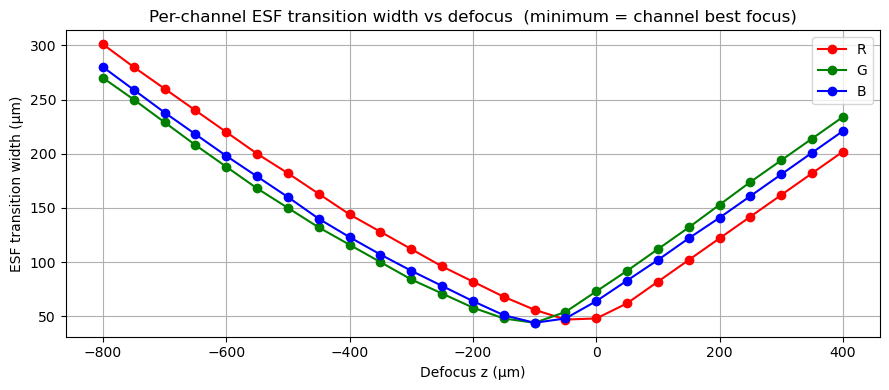

In [6]:
# ── ESF transition width vs defocus ──────────────────────────────────────────
print(f"{'z':>8}  {'R_trans':>8}  {'G_trans':>8}  {'B_trans':>8}")
print("-" * 42)
for _i, _z in enumerate(_z_bake):
    print(f"{_z:>8.0f}  "
          f"{_trans_width['R'][_i]:>8}  {_trans_width['G'][_i]:>8}  {_trans_width['B'][_i]:>8}")

plt.figure(figsize=(9, 4))
for _c, _col in [("R", "r"), ("G", "g"), ("B", "b")]:
    plt.plot(_z_bake, _trans_width[_c], "o-", color=_col, label=_c)
plt.xlabel("Defocus z (µm)")
plt.ylabel("ESF transition width (µm)")
plt.title("Per-channel ESF transition width vs defocus  (minimum = channel best focus)")
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

## 5. Colour Fringe Width & Per-Pair Tone Difference

Now apply tone mapping to the cached raw ESFs and measure colour fringing.

- **CFW (left panel)**: at each defocus $z$, count the number of x-positions where any RGB channel pair differs by more than `COLOR_DIFF_THRESHOLD`. Plotted at exposures 1, 2, 4, 8, 16 to show how scene contrast amplifies fringe visibility.
- **Per-pair max tone difference (remaining panels)**: $\max_x |T_A(x) - T_B(x)|$ for each channel pair (R-G, R-B, G-B). One panel per exposure level, showing how the dominant colour separation shifts with tone-mapping strength.

Note: CFW is **not monotonic** with exposure — at very high exposure, all channels saturate to a hard step, compressing the fringed region.

exp= 1:  max CFW =   1 µm  at z = -250 µm  mean CFW = 0.0 µm
exp= 2:  max CFW =  10 µm  at z = -200 µm  mean CFW = 0.7 µm
exp= 4:  max CFW =  27 µm  at z = -350 µm  mean CFW = 12.8 µm
exp= 8:  max CFW =  42 µm  at z = +250 µm  mean CFW = 30.0 µm
exp=16:  max CFW =  47 µm  at z = +400 µm  mean CFW = 29.4 µm


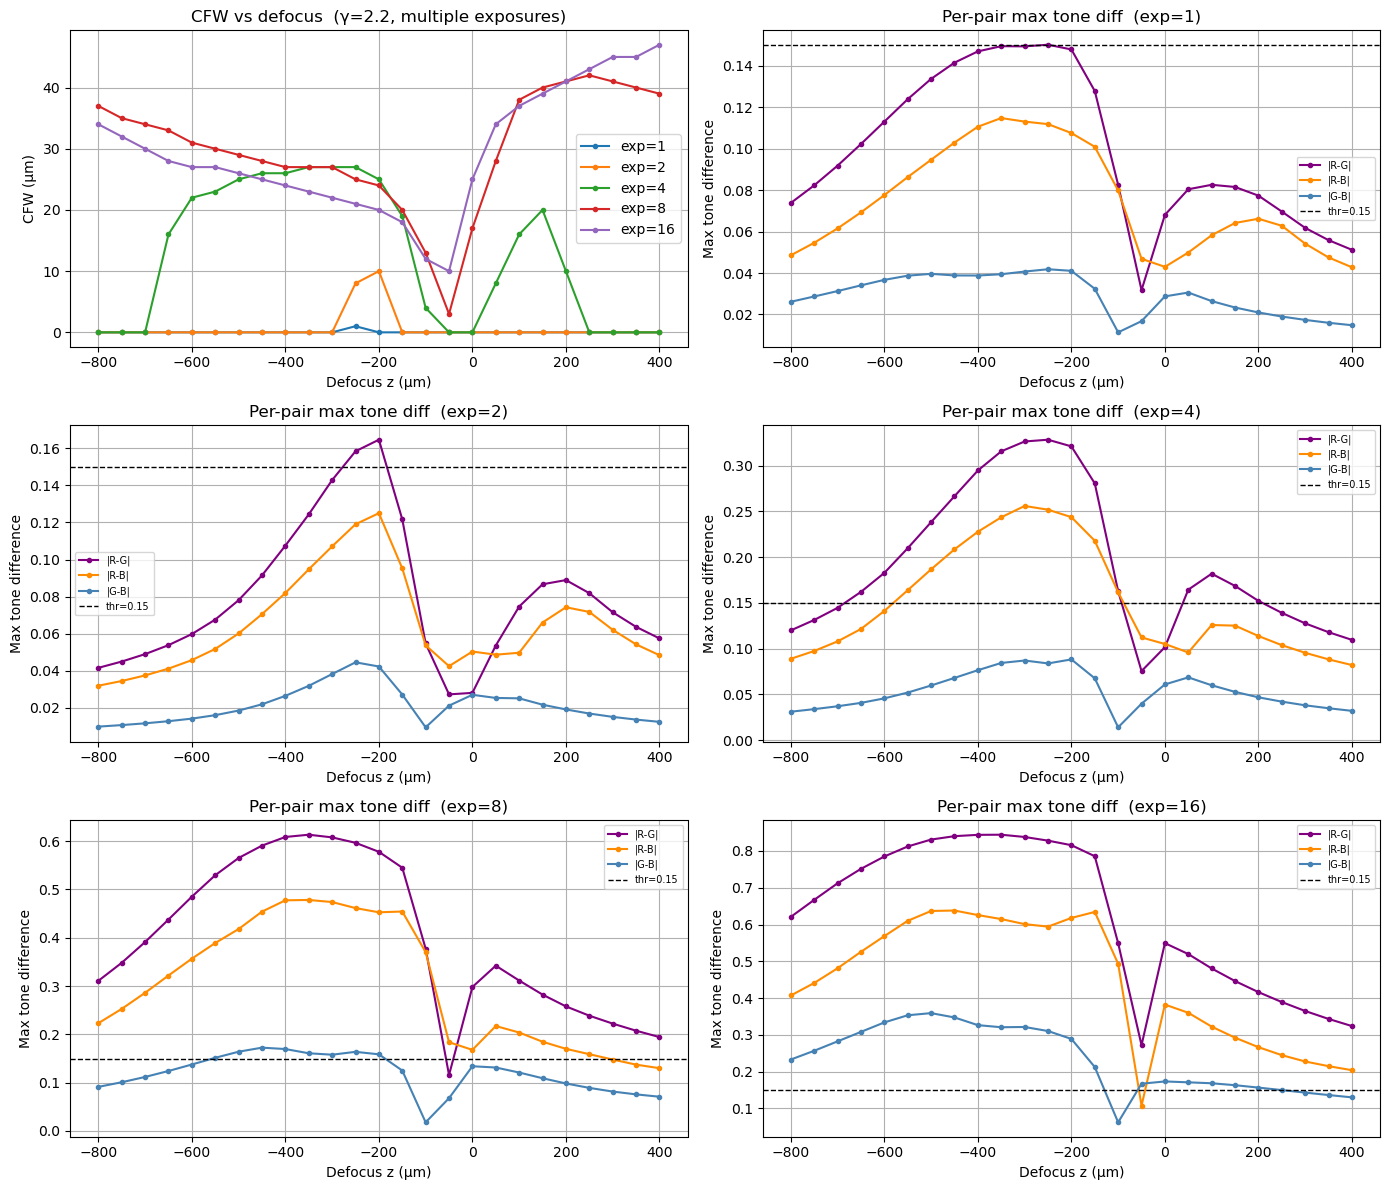

In [7]:
# ── FFTPSF: CFW and per-pair max tone difference vs defocus ──────────────────
_CFW_EXPOSURES = (1, 2, 4, 8, 16)
_DIFF_EXPOSURES = (1, 2, 4, 8, 16)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# ── (0,0) Left-top: CFW at multiple exposures ──
ax_cfw = axes[0, 0]
for _exp in _CFW_EXPOSURES:
    _cfw_exp = np.zeros(len(_z_bake), dtype=np.int32)
    for _i in range(len(_z_bake)):
        _esfs_exp = {_c: _tone_map(_esf_raw_cache[(_i, _c)], exposure=_exp)
                     for _c in ("R", "G", "B")}
        _fringed_exp = (
            (np.abs(_esfs_exp["R"] - _esfs_exp["G"]) > COLOR_DIFF_THRESHOLD)
            | (np.abs(_esfs_exp["R"] - _esfs_exp["B"]) > COLOR_DIFF_THRESHOLD)
            | (np.abs(_esfs_exp["G"] - _esfs_exp["B"]) > COLOR_DIFF_THRESHOLD)
        )
        _cfw_exp[_i] = int(_fringed_exp.sum())
    ax_cfw.plot(_z_bake, _cfw_exp, "o-", ms=3, label=f"exp={_exp}")
    _peak_z = _z_bake[_cfw_exp.argmax()]
    print(f"exp={_exp:>2}:  max CFW = {_cfw_exp.max():>3} µm  at z = {_peak_z:+.0f} µm  "
          f"mean CFW = {_cfw_exp.mean():.1f} µm")

ax_cfw.set(title=f"CFW vs defocus  (γ={GAMMA_DEFAULT}, multiple exposures)",
           xlabel="Defocus z (µm)", ylabel="CFW (µm)")
ax_cfw.legend(); ax_cfw.grid(True)

# ── Remaining slots: per-pair max tone diff at each exposure ──
_PAIR_COLORS = {"R-G": "purple", "R-B": "darkorange", "G-B": "steelblue"}
_slot_axes = [axes[0, 1], axes[1, 0], axes[1, 1], axes[2, 0], axes[2, 1]]

for _si, _exp in enumerate(_DIFF_EXPOSURES):
    _ax = _slot_axes[_si]
    _pd_exp = {"R-G": np.zeros(len(_z_bake)),
               "R-B": np.zeros(len(_z_bake)),
               "G-B": np.zeros(len(_z_bake))}
    for _i in range(len(_z_bake)):
        _esfs_exp = {_c: _tone_map(_esf_raw_cache[(_i, _c)], exposure=_exp)
                     for _c in ("R", "G", "B")}
        _pd_exp["R-G"][_i] = np.abs(_esfs_exp["R"] - _esfs_exp["G"]).max()
        _pd_exp["R-B"][_i] = np.abs(_esfs_exp["R"] - _esfs_exp["B"]).max()
        _pd_exp["G-B"][_i] = np.abs(_esfs_exp["G"] - _esfs_exp["B"]).max()
    for _pair, _col in _PAIR_COLORS.items():
        _ax.plot(_z_bake, _pd_exp[_pair], "o-", ms=3, color=_col, label=f"|{_pair}|")
    _ax.axhline(COLOR_DIFF_THRESHOLD, color="k", ls="--", lw=1,
                label=f"thr={COLOR_DIFF_THRESHOLD}")
    _ax.set(title=f"Per-pair max tone diff  (exp={_exp})",
            xlabel="Defocus z (µm)", ylabel="Max tone difference")
    _ax.legend(fontsize=7); _ax.grid(True)

plt.tight_layout(); plt.show()

## 6. Per-Defocus ESF Diagnostic

Detailed per-$z$ visualization of the edge response. Each row shows one defocus position with three columns:

1. **Raw ESF** — linear polychromatic edge response (pure optics)
2. **Tone-mapped ESF** — after applying exposure and gamma, with fringe boundary markers (black dashed)
3. **Pseudo-density fringe map** — RGB ESF rendered as a colour strip, with fringe boundaries (white dashed)

Change `DIAG_EXPOSURE` at the top of the cell and re-run to see how different exposure levels affect the visible fringe pattern. No re-baking needed.

Exposure = 4  |  γ = 2.2  |  threshold = 0.15
Plotting 23 z points from -800 to +300 µm

  z (µm)    CFW   max_diff   R_tr   G_tr   B_tr
--------------------------------------------------
    -800      0     0.1200    301    270    280
    -750      0     0.1314    280    250    259
    -700      0     0.1447    260    229    238
    -650     16     0.1621    240    208    218
    -600     22     0.1829    220    188    198
    -550     23     0.2098    200    168    179
    -500     25     0.2383    182    150    160
    -450     26     0.2667    163    132    140
    -400     26     0.2948    144    116    123
    -350     27     0.3157    128    100    107
    -300     27     0.3265    112     84     92
    -250     27     0.3284     96     71     78
    -200     25     0.3211     82     58     64
    -150     19     0.2807     68     48     51
    -100      4     0.1629     56     44     44
     -50      0     0.1123     47     54     48
      +0      0     0.1052     48     73    

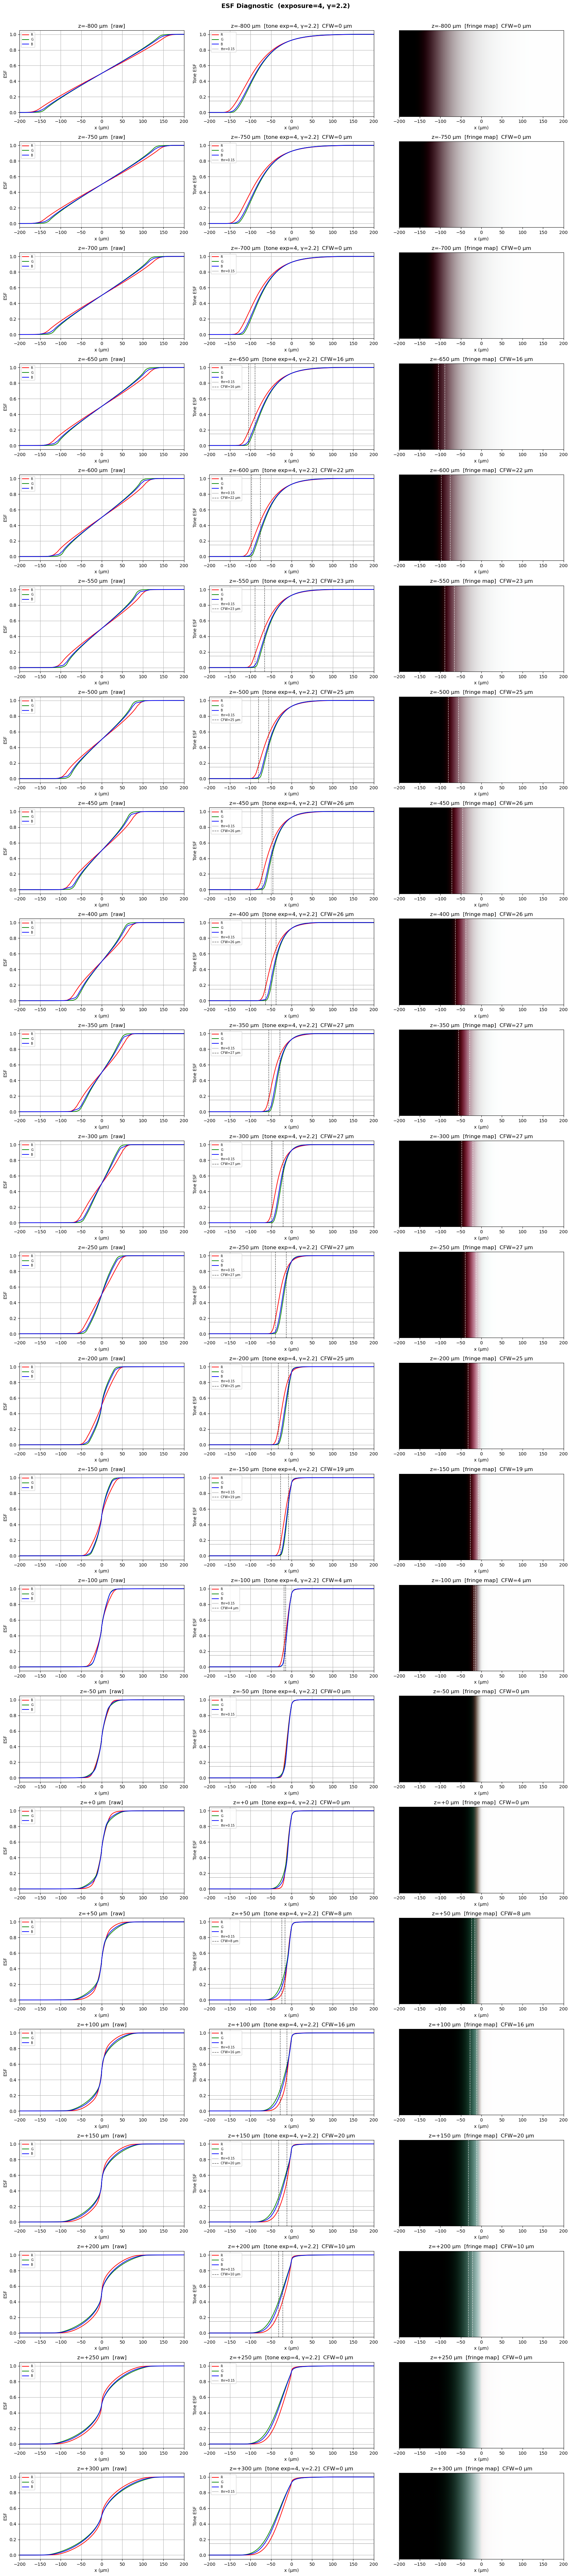

In [13]:
# ── ESF diagnostic: all baked z from -800 to +300 (uses cached ESFs) ─────────
# ┌─────────────────────────────────────────────────────────────────┐
# │  User setting: change DIAG_EXPOSURE below and re-run this cell │
# └─────────────────────────────────────────────────────────────────┘
DIAG_EXPOSURE = 4          # ← set to 1, 2, 4, 8, or 16

_IMG_HEIGHT = 60   # pseudo-density strip height (px)
_DIAG_Z_MAX = 300  # upper z limit for diagnostic plots

# Select all baked z points within range
_diag_mask = _z_bake <= _DIAG_Z_MAX
_diag_indices = np.flatnonzero(_diag_mask)

print(f"Exposure = {DIAG_EXPOSURE}  |  γ = {GAMMA_DEFAULT}  |  threshold = {COLOR_DIFF_THRESHOLD}")
print(f"Plotting {len(_diag_indices)} z points from {_z_bake[_diag_indices[0]]:+.0f} "
      f"to {_z_bake[_diag_indices[-1]]:+.0f} µm\n")

print(f"{'z (µm)':>8}  {'CFW':>5}  {'max_diff':>9}  {'R_tr':>5}  {'G_tr':>5}  {'B_tr':>5}")
print("-" * 50)
for _i in _diag_indices:
    _esfs_diag = {_c: _tone_map(_esf_raw_cache[(_i, _c)], exposure=DIAG_EXPOSURE)
                  for _c in ("R", "G", "B")}
    _md = max(np.abs(_esfs_diag["R"] - _esfs_diag["G"]).max(),
              np.abs(_esfs_diag["R"] - _esfs_diag["B"]).max(),
              np.abs(_esfs_diag["G"] - _esfs_diag["B"]).max())
    _fr = ((np.abs(_esfs_diag["R"] - _esfs_diag["G"]) > COLOR_DIFF_THRESHOLD)
           | (np.abs(_esfs_diag["R"] - _esfs_diag["B"]) > COLOR_DIFF_THRESHOLD)
           | (np.abs(_esfs_diag["G"] - _esfs_diag["B"]) > COLOR_DIFF_THRESHOLD))
    print(f"{_z_bake[_i]:>+8.0f}  {int(_fr.sum()):>5}  {_md:>9.4f}  "
          f"{_trans_width['R'][_i]:>5}  {_trans_width['G'][_i]:>5}  {_trans_width['B'][_i]:>5}")

# Plot (3 columns: raw, tone, fringe map)
_n = len(_diag_indices)
fig, _axes = plt.subplots(_n, 3, figsize=(18, 3.5 * _n), squeeze=False,
                          gridspec_kw={"width_ratios": [1, 1, 1]})
_xlim = (-200, 200)

for _row, _i in enumerate(_diag_indices):
    _z_val = float(_z_bake[_i])

    # Raw ESF from cache; tone-map at user-selected exposure
    _raw      = {_c: _esf_raw_cache[(_i, _c)] for _c in ("R", "G", "B")}
    _tone_esf = {_c: _tone_map(_raw[_c], exposure=DIAG_EXPOSURE)
                 for _c in ("R", "G", "B")}

    # Fringe boundary detection
    _fringed = (
        (np.abs(_tone_esf["R"] - _tone_esf["G"]) > COLOR_DIFF_THRESHOLD) |
        (np.abs(_tone_esf["R"] - _tone_esf["B"]) > COLOR_DIFF_THRESHOLD) |
        (np.abs(_tone_esf["G"] - _tone_esf["B"]) > COLOR_DIFF_THRESHOLD)
    )
    _jumps = np.flatnonzero(np.diff(_fringed.astype(int), prepend=_fringed[0]))
    _cfw = int(_fringed.sum())
    _lbl = f"z={_z_val:+.0f} µm"

    # Column 0: raw ESF
    for _c, _col in [("R", "r"), ("G", "g"), ("B", "b")]:
        _axes[_row, 0].plot(_X_UM, _raw[_c],      color=_col, label=_c, lw=1.5)
        _axes[_row, 1].plot(_X_UM, _tone_esf[_c], color=_col, label=_c, lw=1.5)
    _axes[_row, 0].set(title=f"{_lbl}  [raw]",
                       xlabel="x (µm)", ylabel="ESF", xlim=_xlim)

    # Column 1: tone-mapped ESF + threshold + fringe boundaries
    _axes[_row, 1].axhline(COLOR_DIFF_THRESHOLD, color="k", ls=":", lw=0.8,
                           label=f"thr={COLOR_DIFF_THRESHOLD}")
    for _ji, _jidx in enumerate(_jumps):
        _axes[_row, 1].axvline(_X_UM[_jidx], color="k", ls="--", lw=1, alpha=0.7,
                               label=f"CFW={_cfw} µm" if _ji == 0 else None)
    _axes[_row, 1].set(title=f"{_lbl}  [tone exp={DIAG_EXPOSURE}, γ={GAMMA_DEFAULT}]  CFW={_cfw} µm",
                       xlabel="x (µm)", ylabel="Tone ESF", xlim=_xlim)

    # Column 2: pseudo-density fringe map + fringe boundaries
    _img_row = np.stack([_tone_esf["R"], _tone_esf["G"], _tone_esf["B"]], axis=1)
    _img = np.repeat(np.clip(_img_row, 0, 1)[:, None, :], _IMG_HEIGHT, axis=1)
    _axes[_row, 2].imshow(
        _img.swapaxes(0, 1),
        extent=(float(_X_UM.min()), float(_X_UM.max()), 0.0, float(_IMG_HEIGHT)),
        aspect="auto", origin="lower",
    )
    for _jidx in _jumps:
        _axes[_row, 2].axvline(_X_UM[_jidx], color="w", ls="--", lw=1, alpha=0.8)
    _axes[_row, 2].set_xlim(_xlim)
    _axes[_row, 2].set_xlabel("x (µm)"); _axes[_row, 2].set_yticks([])
    _axes[_row, 2].set_title(f"{_lbl}  [fringe map]  CFW={_cfw} µm")

    for _ax in _axes[_row, :2]:
        _ax.legend(fontsize=7); _ax.grid(True)

plt.suptitle(f"ESF Diagnostic  (exposure={DIAG_EXPOSURE}, γ={GAMMA_DEFAULT})",
             fontsize=14, fontweight="bold", y=1.002)
plt.tight_layout(); plt.show()